In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)
plt.rcParams["figure.figsize"] = (5,3)
# Getting the data
seattle_url = "https://assets.datacamp.com/production/repositories/3634/datasets/6fd451508ecce0d63354fad86704236592eed8ca/seattle_weather.csv"
austin_url = "https://assets.datacamp.com/production/repositories/3634/datasets/e76b460b41dc7ff286d78246daf3a8c324cb5587/austin_weather.csv"
df1 = pd.read_csv(seattle_url)
df2 = pd.read_csv(austin_url)
seattle = df1.copy()
austin = df2.copy()
seattle_weather = seattle.iloc[0:12, :] # Subset
austin_weather = austin.iloc[0:12, :] # Subset

In [121]:
# Change the numerical Month column to a factor Month column
seattle_weather['DATE'] = seattle_weather['DATE'].astype('category')
month_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
seattle_weather['DATE'] = seattle_weather['DATE'].map(month_map)
seattle_weather.rename(columns={'DATE':'MONTH'}, inplace= True)
seattle_weather.head()

,STATION,NAME,MONTH,MLY-CLDD-BASE45,MLY-CLDD-BASE50,MLY-CLDD-BASE55,MLY-CLDD-BASE57,MLY-CLDD-BASE60,MLY-CLDD-BASE70,MLY-CLDD-BASE72,...,MLY-TMIN-AVGNDS-LSTH060,MLY-TMIN-AVGNDS-LSTH070,MLY-TMIN-NORMAL,MLY-TMIN-PRBOCC-LSTH016,MLY-TMIN-PRBOCC-LSTH020,MLY-TMIN-PRBOCC-LSTH024,MLY-TMIN-PRBOCC-LSTH028,MLY-TMIN-PRBOCC-LSTH032,MLY-TMIN-PRBOCC-LSTH036,MLY-TMIN-STDDEV
0,USC00456295,"PALMER 3 ESE, WA US",Jan,13.0,1.0,-7777.0,0.0,0.0,0.0,0.0,...,310.0,310.0,34.0,168.0,327.0,615.0,877.0,987.0,1000.0,2.8
1,USC00456295,"PALMER 3 ESE, WA US",Feb,23.0,3.0,-7777.0,-7777.0,0.0,0.0,0.0,...,280.0,280.0,33.9,132.0,275.0,515.0,800.0,963.0,1000.0,3.1
2,USC00456295,"PALMER 3 ESE, WA US",Mar,50.0,11.0,1.0,-7777.0,-7777.0,0.0,0.0,...,310.0,310.0,35.9,5.0,47.0,111.0,393.0,848.0,1000.0,2.1
3,USC00456295,"PALMER 3 ESE, WA US",Apr,108.0,40.0,12.0,7.0,3.0,-7777.0,0.0,...,300.0,300.0,38.3,0.0,0.0,5.0,123.0,571.0,978.0,2.0
4,USC00456295,"PALMER 3 ESE, WA US",May,255.0,130.0,56.0,38.0,19.0,1.0,-7777.0,...,310.0,310.0,43.5,0.0,0.0,0.0,0.0,83.0,610.0,2.0


In [122]:
# Same for austin dataset
austin_weather['DATE'] = austin_weather['DATE'].astype('category').map(month_map)
austin_weather.rename(columns={'DATE':'MONTH'}, inplace= True)
austin_weather.head()

,STATION,NAME,MONTH,MLY-CLDD-BASE45,MLY-CLDD-BASE50,MLY-CLDD-BASE55,MLY-CLDD-BASE57,MLY-CLDD-BASE60,MLY-CLDD-BASE70,MLY-CLDD-BASE72,...,MLY-TMIN-AVGNDS-LSTH060,MLY-TMIN-AVGNDS-LSTH070,MLY-TMIN-NORMAL,MLY-TMIN-PRBOCC-LSTH016,MLY-TMIN-PRBOCC-LSTH020,MLY-TMIN-PRBOCC-LSTH024,MLY-TMIN-PRBOCC-LSTH028,MLY-TMIN-PRBOCC-LSTH032,MLY-TMIN-PRBOCC-LSTH036,MLY-TMIN-STDDEV
0,USW00013904,"AUSTIN BERGSTROM INTERNATIONAL AIRPORT, TX US",Jan,190,103,50,35,18,1,-7777,...,302,310,36.3,298,570,839,967,997,1000,2.9
1,USW00013904,"AUSTIN BERGSTROM INTERNATIONAL AIRPORT, TX US",Feb,228,132,68,49,29,3,1,...,264,280,39.4,103,327,614,867,973,999,3.2
2,USW00013904,"AUSTIN BERGSTROM INTERNATIONAL AIRPORT, TX US",Mar,446,306,185,146,98,13,6,...,270,308,46.6,10,73,242,494,761,928,3.6
3,USW00013904,"AUSTIN BERGSTROM INTERNATIONAL AIRPORT, TX US",Apr,668,519,373,318,240,53,32,...,193,287,54.7,0,0,0,48,189,453,4.1
4,USW00013904,"AUSTIN BERGSTROM INTERNATIONAL AIRPORT, TX US",May,936,781,626,564,471,181,134,...,89,250,63.7,0,0,0,0,0,0,2.5


# 1. Data Visualisation with Matplotlib

## 1.1 Interface

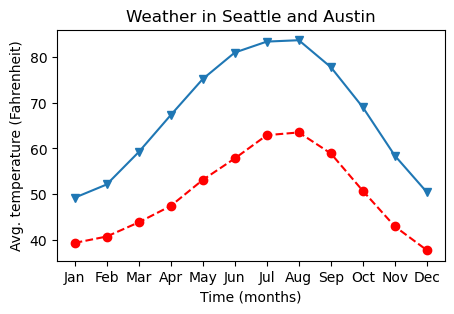

In [123]:
fig, ax = plt.subplots() # Setup the pyplot interface
ax.plot(seattle_weather["MONTH"], seattle_weather['MLY-TAVG-NORMAL'], marker = 'o', 
        linestyle = '--', color = 'r')
ax.plot(austin_weather["MONTH"], austin_weather["MLY-TAVG-NORMAL"], marker = 'v')
ax.set_xlabel("Time (months)")
ax.set_ylabel("Avg. temperature (Fahrenheit)")
ax.set_title("Weather in Seattle and Austin")
plt.show()

## 1.2 Subplots

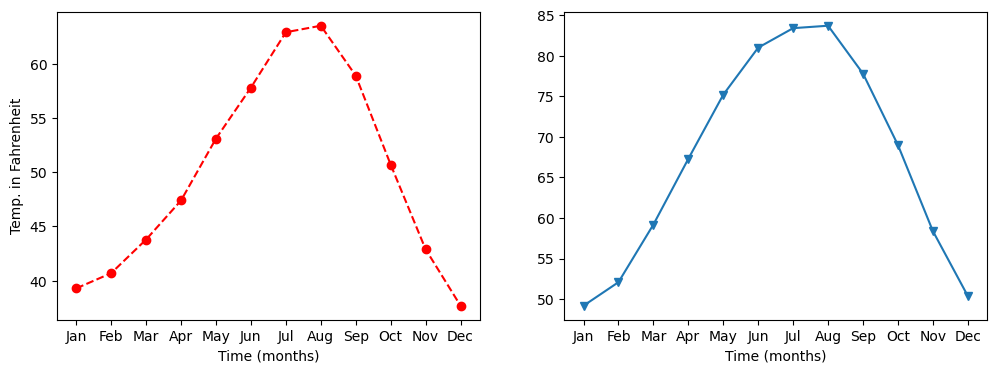

In [124]:
fig, ax = plt.subplots(1,2, figsize = (12,4), sharex=True)
ax[0].plot(seattle_weather["MONTH"], seattle_weather['MLY-TAVG-NORMAL'], marker = 'o', 
        linestyle = '--', color = 'r')
ax[1].plot(austin_weather["MONTH"], austin_weather["MLY-TAVG-NORMAL"], marker = 'v')
ax[0].set_xlabel("Time (months)")
ax[1].set_xlabel("Time (months)")
ax[0].set_ylabel("Temp. in Fahrenheit")
plt.show()

### 1.3 Time-series data

In [ ]:
# Load the data and choose 'date' as the index (as date format)
climate_url = "https://assets.datacamp.com/production/repositories/3634/datasets/411add3f8570d5adf891127fd64095020210711b/climate_change.csv"
climate_change = pd.read_csv(climate_url, parse_dates=['date'], index_col='date')
climate_change.head()

,co2,relative_temp
date,,
1958-03-06,315.71,0.10
1958-04-06,317.45,0.01
1958-05-06,317.50,0.08
1958-06-06,NaN,-0.05
1958-07-06,315.86,0.06


In [ ]:
# Reusable plotting function
def plot_timeseries(axes, x, y, color, xlabel, ylabel):
    axes.plot(x, y, color = color)
    axes.tick_params('y', colors = color)
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)

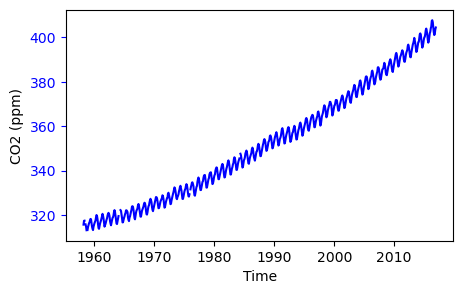

In [142]:
# Plot the data
fig, ax = plt.subplots()
plot_timeseries(ax, climate_change.index, climate_change['co2'], 'blue', 'Time', 'CO2 (ppm)')
plt.show()

#### Text Annotation

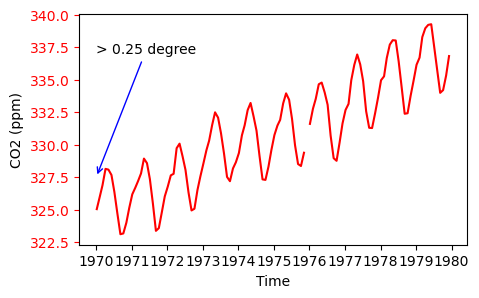

In [152]:
# Zooming in
seventies = climate_change['1970-01-01':"1979-12-31"]
fig, ax = plt.subplots()
plot_timeseries(ax, seventies.index, seventies['co2'], 'red', 'Time', 'CO2 (ppm)')
ax.annotate("> 0.25 degree",
            xy = (pd.Timestamp('1970-01-01'), 327.5),
            xytext=(pd.Timestamp('1970-01-01'), 337),
            arrowprops={"arrowstyle":"->", "color":"blue"})
plt.show()